# Lecture 16: Statistics and Assessing Models
v.ekc

Today we cross from probability into **inference**: a *parameter* describes a population, a *statistic* describes a sample, and simulating a statistic tells us what samples *should* look like, so we can judge models against reality.

**Today's sections:**
1. Random sampling, recapped
2. Distributions, recapped
3. Large random samples
4. Statistics and parameters
5. The empirical distribution of a statistic
6. Sample proportions and Swain v. Alabama

In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

---
## 1. Random Sampling, Recapped

The United flights again: deterministic samples first, then a random one....a copy from last lecture...

We load in a dataset of all United national flights from 6/1/15 to 8/9/15, their destination and how long they were delayed, in minutes.

In [2]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


Some deterministic samples:

In [ ]:
united.take(np.arange(10))

In [ ]:
united.where('Destination', 'JFK') 

Two more deterministic picks: every 1000th row, then three hand-chosen rows:

In [ ]:
united.take(np.arange(0, united.num_rows, 1000))

In [ ]:
united.take(make_array(34, 6321, 10040))

A random sample:

In [ ]:
start = np.random.choice(np.arange(1000))
systematic_sample = united.take(np.arange(start, united.num_rows, 1000))
systematic_sample.show()

---
## 2. Distributions, Recapped

Probability distribution (the die's true 1/6-per-face) vs. empirical distribution (what your rolls actually did).

In [ ]:
die = Table().with_column('Face', np.arange(1, 7))
die

In [ ]:
die.sample(10)

To draw histograms we need bins, one bin per face:

In [ ]:
roll_bins = np.arange(0.5, 6.6, 1)

In [ ]:
die.hist(bins=roll_bins)

That was the true distribution. Now the empirical distribution of just 10 rolls:

In [ ]:
die.sample(10).hist(bins=roll_bins)

### Try It 1: Law of Averages reps 😊

1. Simulate 1000 rolls and plot the empirical distribution. Compare to 10 rolls.

2. Now 10,000 rolls.

In [ ]:
# 1. 1000 rolls


In [ ]:
# 2. 10000 rolls


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*More rolls → flatter, closer to the true distribution.*

```python
# 1.
die.sample(1000).hist(bins=roll_bins)

# 2.
die.sample(10000).hist(bins=roll_bins)
```

</details>

---
## 3. Large Random Samples

Same story with real data, the population distribution of flight delays:

In [ ]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

In [ ]:
united_bins = np.arange(-20, 201, 5)
united.hist('Delay', bins = united_bins)

Three parameters of this population: smallest, largest, and average delay:

In [ ]:
min(united.column('Delay'))

In [ ]:
max(united.column('Delay'))

In [ ]:
np.average(united.column('Delay'))

### Try It 2: Sample sizes 😊

1. Draw a sample of 10 flights and plot the delays. What do you observe?

2. Now 1000 flights.

In [ ]:
# 1. sample of 10


In [ ]:
# 2. sample of 1000


<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Ten flights can look like anything; a thousand look like the population.*

```python
# 1.
united.sample(10).hist('Delay', bins=united_bins)

# 2.
united.sample(1000).hist('Delay', bins=united_bins)
```

</details>

---
## 4. Statistics and Parameters 🎯

The vocabulary of inference:

### 📋 Reference Table

| Term | Meaning | Example |
|---|---|---|
| **Parameter** | a number describing the **population** | median delay of *all* flights |
| **Statistic** | a number computed from a **sample** | median delay of 10 sampled flights |
| Key fact | statistics **vary** from sample to sample | run the cells below twice! |
| Inference | using a statistic to estimate a parameter | our project for the next 6 lectures |

In [3]:
# (Population) Parameter
np.median(united.column('Delay'))

2.0

In [4]:
# (Sample) Statistic
np.median(united.sample(10).column('Delay'))

1.5

In [5]:
# (Sample) Statistic
np.median(united.sample(100).column('Delay'))

1.0

### Probability & Empirical Distributions of a Statistic

A statistic is random, so it *has a distribution*. Simulate the statistic many times and you can see it:

In [6]:
def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [7]:
sample_median(10)

23.5

Run that line a few times, new sample, new median. Now simulate 2000 of them:

In [8]:
num_simulations = 2000

In [9]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(10)
    sample_medians = np.append(sample_medians, new_median)

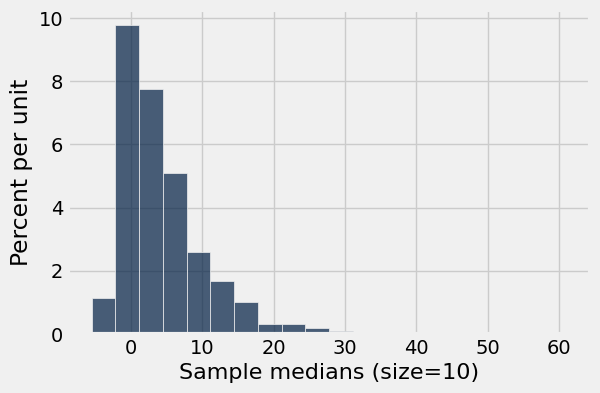

In [10]:
Table().with_column('Sample medians (size=10)', sample_medians).hist(bins=20)

Same recipe with samples of size 1000. Watch the spread collapse:

In [11]:
sample_medians = make_array()

for i in np.arange(num_simulations):
    new_median = sample_median(1000)
    sample_medians = np.append(sample_medians, new_median)

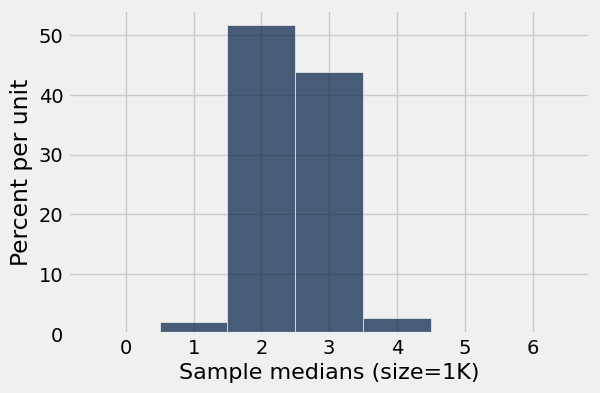

In [12]:
Table().with_column('Sample medians (size=1K)', sample_medians).hist(bins = np.arange(-0.5,7.5))

#### Empirical Distributions of a Statistic (Overlayed)

In [13]:
sample_medians_10 = make_array()
sample_medians_100 = make_array()
sample_medians_1000 = make_array()

num_simulations = 2000

for i in np.arange(num_simulations):
    new_median_10 = sample_median(10)
    sample_medians_10 = np.append(sample_medians_10, new_median_10)
    new_median_100 = sample_median(100)
    sample_medians_100 = np.append(sample_medians_100, new_median_100)
    new_median_1000 = sample_median(1000)
    sample_medians_1000 = np.append(sample_medians_1000, new_median_1000)

In [18]:
sample_medians = Table().with_columns('Size 10', sample_medians_10, 
                                      'Size 100', sample_medians_100,
                                      'Size 1000', sample_medians_1000)

sample_medians.show(5)

Size 10,Size 100,Size 1000
7.5,2,3
0,0,3
1,2,3
-0.5,2.5,3
0,4,2


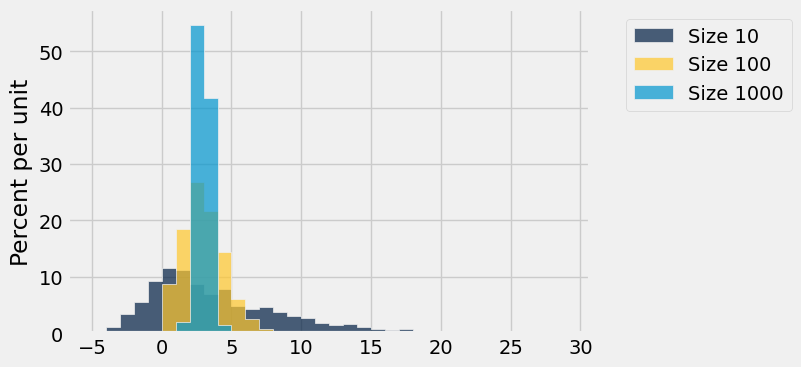

In [15]:
sample_medians.hist(bins = np.arange(-5, 30))

> **Bigger samples → tighter statistic.** The size-1000 medians barely budge; the size-10 medians are all over the place. Sample size buys reliability.

### Try It 3: Sample means 😊

1. Medians are not special: write `sample_mean(size)` and simulate 2000 sample **means** of the delay for samples of size 100. Draw the histogram.

2. Compute the population average delay (the parameter).

3. Where is your histogram centered, compared to the parameter?

In [ ]:
# 1. 2000 sample means, size 100


In [ ]:
# 2. population average


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Same simulation recipe, different statistic.*

```python
# 1.
def sample_mean(size):
    return np.average(united.sample(size).column('Delay'))

sample_means = make_array()
for i in np.arange(2000):
    sample_means = np.append(sample_means, sample_mean(100))
Table().with_column('Sample means (size=100)', sample_means).hist(bins=20)

# 2.
np.average(united.column('Delay'))
```

*3. The sample means pile up around 16.7 minutes, the population average. Statistics estimate parameters.*

</details>

---
## 5. Sample Proportions

`sample_proportions(n, dist)` simulates drawing `n` individuals from a categorical distribution and returns the sampled *proportions*, one function that replaces a whole `for` loop. You'll use it constantly (Lab 6, Homework 5).

### An Unfair Coin

Say I have an unfair coin. With 40% chance of flipping heads and 60% chance of flipping tails.

In [ ]:
unfair_coin_proportions = make_array(0.4,0.6)
sample_proportions(100,unfair_coin_proportions)

### Try It 4: Proportion practice 😊

1. Use `sample_proportions` to flip the unfair coin just 10 times. Run the cell a few times.

2. Now 10,000 flips, a few times.

3. Which sample size gives proportions that stay close to (0.4, 0.6), and why?

In [ ]:
# 1. 10 flips


In [ ]:
# 2. 10,000 flips


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Same function, only the sample size changes.*

```python
# 1.
sample_proportions(10, unfair_coin_proportions)

# 2.
sample_proportions(10000, unfair_coin_proportions)
```

*3. The 10,000-flip proportions barely move from (0.4, 0.6); the 10-flip ones jump around. The Law of Averages again: bigger samples, steadier proportions.*

</details>

---
## 6. Swain v. Alabama ⚖️

In Talladega County, Alabama, 1965, 26% of eligible jurors were Black men, yet Robert Swain's 100-person jury panel had only 8. The Supreme Court called this acceptable. Let's ask the data: **if panels really were drawn from the eligible population, how many Black men would a panel of 100 have?** 

In [ ]:
population_proportions = make_array(.26, .74)
population_proportions

In [ ]:
sample_proportions(100, population_proportions)

Wrap the draw in a function that returns just the proportion of Black men:

In [ ]:
def panel_proportion():
    return sample_proportions(100, population_proportions).item(0)

In [ ]:
panel_proportion()

Simulate 10,000 panels, saving each count out of 100:

In [ ]:
panels = make_array()

for i in np.arange(10000):
    new_panel = panel_proportion() * 100
    panels = np.append(panels, new_panel)

In [ ]:
Table().with_column(
    'Number of Black Men on Panel of 100', panels
).hist(bins=np.arange(5.5,40.))

# Plotting details; ignore this code
plots.ylim(-0.002, 0.09)
plots.scatter(8, 0, color='red', s=30);

### Try It 5: Judge the model 😊

1. In what fraction of the 10,000 simulated panels were there 8 or fewer Black men? (`panels` is still in memory.)

2. What is the *smallest* count any simulated panel produced?

3. Your verdict on the model, in one sentence.

In [ ]:
# 1. fraction at or below 8


In [ ]:
# 2. smallest simulated count


*3. Your interpretation: (double-click to edit)*

<details>
<summary>💡 Possible answers — click to peek</summary>
<br>

*Boolean counting: each True is worth 1.*

```python
# 1.
sum(panels <= 8) / 10000

# 2.
min(panels)
```

*3. Simulated panels essentially never reach 8 (the minimum is usually around 10 or 11, and the fraction at or below 8 is typically 0 out of 10,000). If panels really were random draws from the eligible population, 8 would be absurdly unlikely, so the model is not believable.*

</details>

> **Read the histogram:** simulated panels essentially *never* dip to 8, the observed value is far outside anything chance produces. The model "panels are random draws from the eligible population" is not believable. That's assessing a model with a statistic, the blueprint for the next three lectures.

---
> **Today's takeaway:** parameters belong to populations, statistics to samples; statistics have distributions you can simulate; and when the observed statistic sits far outside the simulated distribution, the model is in trouble.

## Appendix — Quick Reference

Full `datascience` docs: [data8.org/datascience](https://data8.org/datascience/)

### Minimal template — simulate a statistic
```python
def one_statistic():
    return np.median(population.sample(n).column('col'))

stats = make_array()
for i in np.arange(10000):
    stats = np.append(stats, one_statistic())
Table().with_column('Statistic', stats).hist()
```